In [2]:
%reload_ext autoreload
%autoreload 3
import os
from pathlib import Path
import sys
sys.path.append(str(Path(os.getcwd()).parent / 'src'))
from forecastpnn.utils.data_functions import get_dataset
import torch
torch.use_deterministic_algorithms(True) # reproducibility
import pandas as pd

from forecastpnn.utils.train_utils import SubsetSampler as SS
from forecastpnn.utils.constants import RANDOM_SEED

data = pd.read_csv('../data/derived/DENGSP.csv')
dl = get_dataset(data, 'DT_SIN_PRI', weeks_in=False, weeks_out=False, past_units=30, return_df=True, filter_year_min=2013, filter_year_max=2020, dow=False)


/var/folders/xr/mqd4g8995xqfhcvcyvr2smdc0000gn/T/ipykernel_48208/3552699038.py:15: DtypeWarning: Columns (7,11,23,45,46,47,55,65,69,75,86,102) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/derived/DENGSP.csv')


In [50]:
bounds = [pd.date_range("2013-01-01", "2013-07-01"), pd.date_range("2014-02-01", "2014-07-01"), pd.date_range("2015-01-01", "2015-07-01"), pd.date_range("2015-11-01", "2016-07-01"), pd.date_range("2016-09-01", "2017-07-01"), pd.date_range("2017-08-01", "2018-08-01"), pd.date_range("2019-01-01", "2019-08-01"), pd.date_range("2019-12-15", "2020-07-01")]

from scipy.stats import skewnorm
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import skewnorm
def print_true_outbreak_vs_fitted_values_subs(samples, alpha, mu, sigma, samples_subs = None, density=True, size_based_on_cdf = True):
    num_samples = len(samples)
    # Find size to sample from estimated from subsample
    if samples_subs is not None:
        if size_based_on_cdf:
            prob_until_cutoff = skewnorm.cdf(samples_subs.max(), alpha, mu, sigma)
            num_samples_opt = int(min(len(samples_subs)/prob_until_cutoff, 10_000_000))
        else:
            prob_at_cutoff = skewnorm.pdf(samples_subs.max(), alpha, mu, sigma)
            num_samples_opt = int(min(len(samples_subs[samples_subs == samples_subs.max()])/prob_at_cutoff, 10_000_000))
        samples_opt = skewnorm.rvs(alpha, mu, sigma, size=num_samples_opt, random_state=42)
    else:
        samples_opt = skewnorm.rvs(alpha, mu, sigma, size=num_samples, random_state=42)

    # Create integer bins that cover both datasets
    min_val = int(min(min(samples), min(samples_opt)))
    max_val = int(np.ceil(max(max(samples), max(samples_opt))))
    bins = np.arange(min_val, max_val + 1)

    plt.figure(figsize=(5, 3))
    plt.hist(samples, bins=bins, label='Original Samples', density=density, color = "black")
    if samples_subs is not None:
        plt.hist(samples_subs, bins=bins, label='Original Samples Subs', density=density, color = "dodgerblue")
    plt.hist(samples_opt, bins=bins, alpha=0.8, label='Fitted Samples', density=density, color = "crimson")
    plt.legend(loc='upper right')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.title('Original vs Fitted Skew Normal Distribution')
    plt.show()

------------------------ Outbreak 1 -----------------------


100%|██████████| 1000/1000 [00:05<00:00, 193.44it/s]


Optimized parameters: mu=9.39, sigma=4.03, alpha=8.79, estimate of the mode: 75


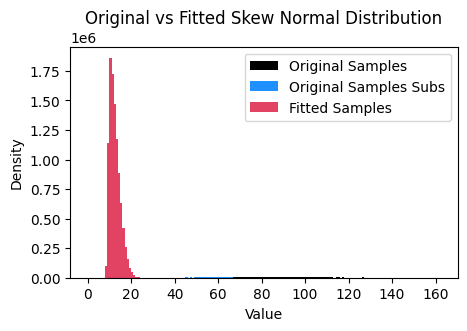

------------------------ Outbreak 2 -----------------------


100%|██████████| 1000/1000 [00:04<00:00, 211.00it/s]


Optimized parameters: mu=8.64, sigma=4.19, alpha=6.82, estimate of the mode: 80


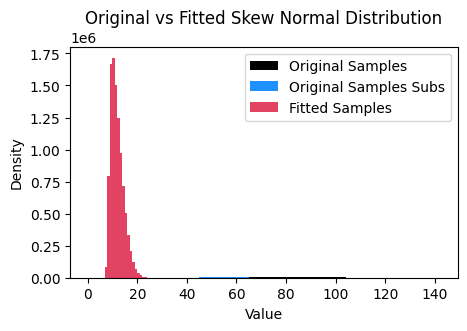

------------------------ Outbreak 3 -----------------------


100%|██████████| 1000/1000 [00:09<00:00, 101.83it/s]


Optimized parameters: mu=9.49, sigma=4.02, alpha=8.46, estimate of the mode: 75


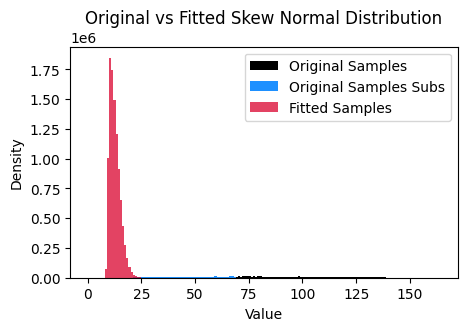

------------------------ Outbreak 4 -----------------------


100%|██████████| 1000/1000 [00:03<00:00, 256.07it/s]


Optimized parameters: mu=8.78, sigma=4.30, alpha=9.06, estimate of the mode: 120


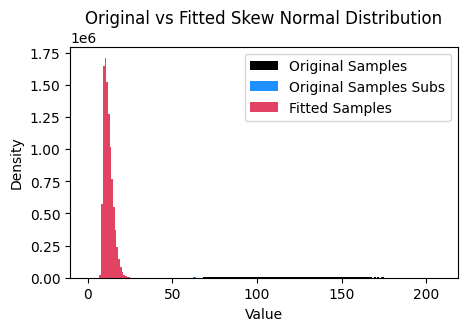

------------------------ Outbreak 5 -----------------------


100%|██████████| 1000/1000 [00:02<00:00, 456.10it/s]


Optimized parameters: mu=117.07, sigma=78.75, alpha=1.55, estimate of the mode: 160


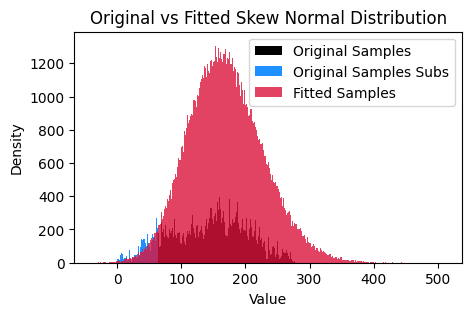

------------------------ Outbreak 6 -----------------------


100%|██████████| 1000/1000 [00:01<00:00, 509.89it/s]


Optimized parameters: mu=47.38, sigma=50.69, alpha=1.56, estimate of the mode: 75


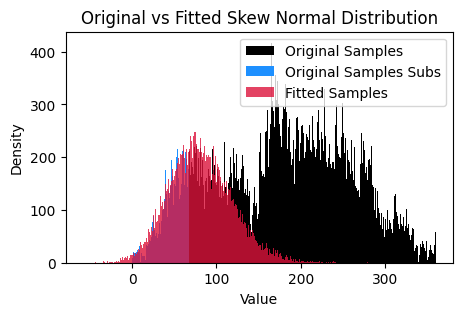

------------------------ Outbreak 7 -----------------------


100%|██████████| 1000/1000 [00:05<00:00, 182.20it/s]


Optimized parameters: mu=6.94, sigma=4.07, alpha=6.43, estimate of the mode: 120


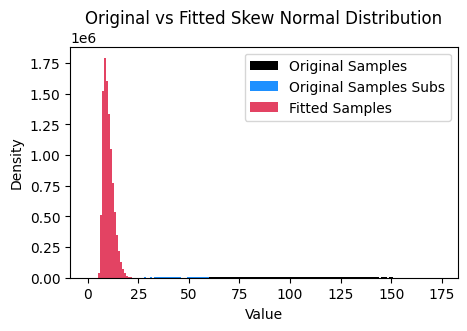

------------------------ Outbreak 8 -----------------------


100%|██████████| 1000/1000 [00:04<00:00, 201.17it/s]


Optimized parameters: mu=6.73, sigma=3.95, alpha=6.96, estimate of the mode: 60


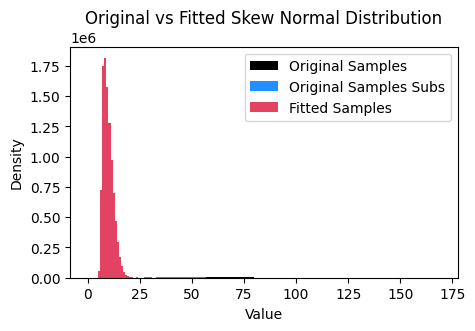

In [56]:
from forecastpnn.models.dist_optimizer import optimize_params

import scipy
from tqdm import tqdm
from scipy.stats import skewnorm

modes = [75, 80, 75, 120, 160, 75, 120, 60]
SAMPLES_SEEN = 70
BOOTSTRAP_ITERS = 5
DECAY = 0.99  # Future idea, problem with pdf to fit and correct calculation of total samples
for i, dr in enumerate(bounds):
    print(f"------------------------ Outbreak {i+1} -----------------------")
    #samples = daily_df.loc[dr, "count"]
    samples = dl.loc[dr, "count"].astype(int)  # Try out with smoothed data
    samples_subs = samples.iloc[:SAMPLES_SEEN].values
    samples_subs = samples_subs - samples.iloc[0]
    samples = samples.values - samples.iloc[0]
    samples_subs = samples_subs[samples_subs > 0]
    samples = samples[samples > 0]
    samples_array = np.repeat(np.arange(len(samples)), samples)
    samples_subs_array = np.repeat(np.arange(len(samples_subs)), samples_subs)
    alpha, mu, sigma = optimize_params(samples_subs_array, peak_loc=modes[i], lambda_loc=1e3, lambda_alpha=1e4)
    print(f"Optimized parameters: mu={mu:.2f}, sigma={sigma:.2f}, alpha={alpha:.2f}, estimate of the mode: {modes[i]}")
    print_true_outbreak_vs_fitted_values_subs(samples_array, alpha, mu, sigma, samples_subs_array, density=False, size_based_on_cdf = False)